In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
!pip install matplotlib

In [7]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [8]:
df_train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [9]:
df_test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [10]:
df_train.shape

(77299, 11)

In [11]:
df_test.shape

(41778, 10)

In [12]:
df_train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [13]:
df_test.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [14]:
df_train['RoadType'].unique()

<StringArray>
[nan, 'Residential', 'Street', 'Highway']
Length: 4, dtype: str

In [15]:
df_train['Temperature'].unique()

array([        nan, 31.1045646 , 25.91926732, ..., 19.67885975,
       22.57395805,  1.32203433], shape=(74805,))

In [16]:
df_train['Weather'].unique()

<StringArray>
[nan, 'Sunny', 'Rainy', 'Foggy', 'Snowy']
Length: 5, dtype: str

In [17]:
cols = df_train.columns

In [18]:
numerical_cols = df_train.select_dtypes(include=['number']).columns.tolist()

categorical_cols = df_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


/var/folders/bt/rq95bpsn1p52vv1d4qhhy0bw0000gn/T/ipykernel_10922/3797447017.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [19]:
numerical_cols

['Index', 'day', 'demand', 'NumberofLanes', 'Temperature']

In [20]:
categorical_cols

['geohash', 'timestamp', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

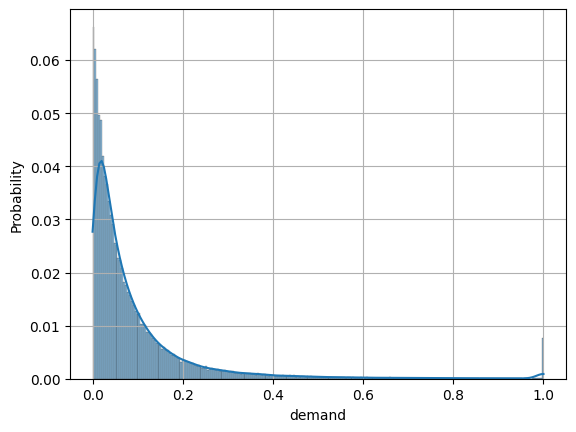

In [21]:
sns.histplot(data=df_train, x='demand', stat='probability', kde=True)
plt.grid(True)
plt.show()

In [22]:
# to be noted demand is right skewed need to use log normalisation
df_train['demand'].skew()

np.float64(3.7285172887316627)

In [23]:
categorical_cols

['geohash', 'timestamp', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

In [24]:
null_cols = ['RoadType', 'Temperature', 'Weather']

<Axes: xlabel='RoadType', ylabel='count'>

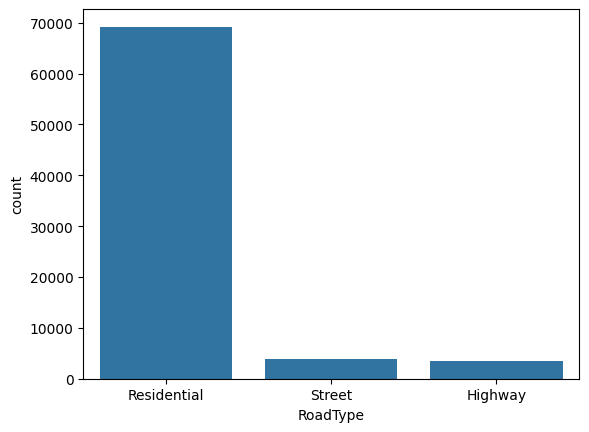

In [25]:
sns.countplot(df_train, x='RoadType')

<Axes: xlabel='Weather', ylabel='count'>

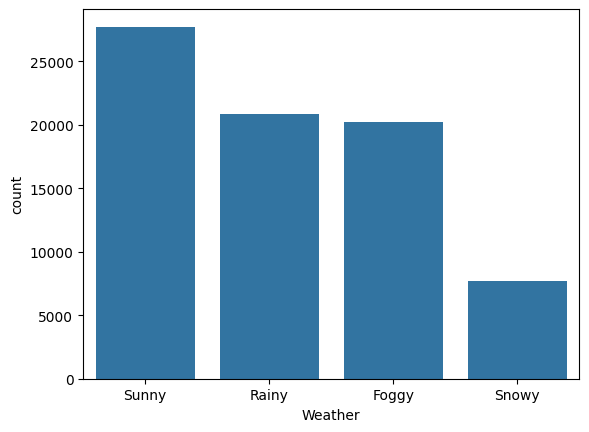

In [26]:
sns.countplot(df_train, x='Weather')


<Axes: xlabel='Temperature', ylabel='Probability'>

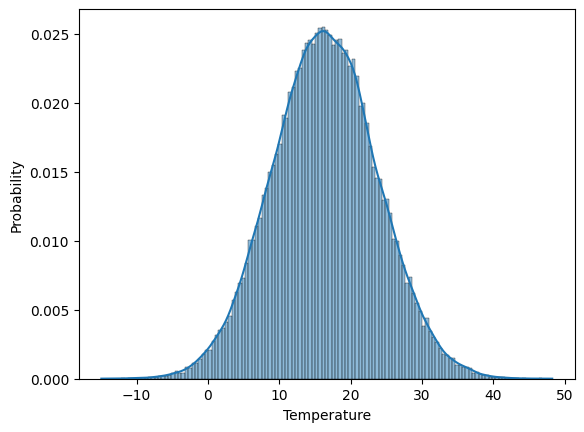

In [27]:
sns.histplot(df_train, x='Temperature', stat = 'probability', kde = True)

In [28]:
from sklearn.impute import SimpleImputer
road_imputer = SimpleImputer(strategy='most_frequent')
weather_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

In [29]:
# 1. Use .copy() to safely duplicate the dataframe
transform_df = df_train.copy()

# Flatten the 2D output into 1D
transform_df['RoadType'] = road_imputer.fit_transform(transform_df[['RoadType']]).ravel()
transform_df['Weather'] = weather_imputer.fit_transform(transform_df[['Weather']]).ravel()

In [30]:
transform_df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,Residential,1,Not Allowed,No,NaN,Unknown
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [31]:
transform_df['RoadType'].unique()

<StringArray>
['Residential', 'Street', 'Highway']
Length: 3, dtype: str

In [32]:
transform_df['Weather'].unique()

<StringArray>
['Unknown', 'Sunny', 'Rainy', 'Foggy', 'Snowy']
Length: 5, dtype: str

In [33]:
transform_df['Temperature'] = transform_df['Temperature'].fillna(transform_df['Temperature'].mean())


In [34]:
encoded_df = pd.get_dummies(df_train, columns=['RoadType', 'LargeVehicles', 'Weather'], dtype=int)

In [35]:
encoded_df

,Index,geohash,day,timestamp,demand,NumberofLanes,Landmarks,Temperature,RoadType_Highway,RoadType_Residential,RoadType_Street,LargeVehicles_Allowed,LargeVehicles_Not Allowed,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny
0,0,qp02z1,48,0:0,0.048804,1,No,NaN,0,0,0,0,1,0,0,0,0
1,1,qp02zt,48,0:0,0.118507,3,Yes,31.104565,0,1,0,1,0,0,0,0,1
2,2,qp08bj,48,0:0,0.027132,1,No,25.919267,0,1,0,0,1,0,0,0,1
3,3,qp08gt,48,0:0,0.003272,1,No,NaN,0,1,0,0,1,0,1,0,0
4,4,qp02zq,48,0:0,0.010819,1,No,10.803667,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,1,No,11.501664,0,1,0,0,1,0,1,0,0
77295,77295,qp0d4q,49,2:0,0.022859,3,Yes,14.715254,0,1,0,1,0,1,0,0,0
77296,77296,qp0d4w,49,2:0,0.141342,3,Yes,19.678860,0,1,0,1,0,0,0,0,1
77297,77297,qp0dhw,49,2:0,0.087574,1,No,22.573958,0,1,0,0,1,0,0,0,1


In [36]:
encoded_df['Landmarks'] = (encoded_df['Landmarks'] == "Yes").astype(int)

In [37]:
encoded_df

,Index,geohash,day,timestamp,demand,NumberofLanes,Landmarks,Temperature,RoadType_Highway,RoadType_Residential,RoadType_Street,LargeVehicles_Allowed,LargeVehicles_Not Allowed,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny
0,0,qp02z1,48,0:0,0.048804,1,0,NaN,0,0,0,0,1,0,0,0,0
1,1,qp02zt,48,0:0,0.118507,3,1,31.104565,0,1,0,1,0,0,0,0,1
2,2,qp08bj,48,0:0,0.027132,1,0,25.919267,0,1,0,0,1,0,0,0,1
3,3,qp08gt,48,0:0,0.003272,1,0,NaN,0,1,0,0,1,0,1,0,0
4,4,qp02zq,48,0:0,0.010819,1,0,10.803667,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,1,0,11.501664,0,1,0,0,1,0,1,0,0
77295,77295,qp0d4q,49,2:0,0.022859,3,1,14.715254,0,1,0,1,0,1,0,0,0
77296,77296,qp0d4w,49,2:0,0.141342,3,1,19.678860,0,1,0,1,0,0,0,0,1
77297,77297,qp0dhw,49,2:0,0.087574,1,0,22.573958,0,1,0,0,1,0,0,0,1


In [38]:
print(encoded_df.isnull().sum())

Index                           0
geohash                         0
day                             0
timestamp                       0
demand                          0
NumberofLanes                   0
Landmarks                       0
Temperature                  2495
RoadType_Highway                0
RoadType_Residential            0
RoadType_Street                 0
LargeVehicles_Allowed           0
LargeVehicles_Not Allowed       0
Weather_Foggy                   0
Weather_Rainy                   0
Weather_Snowy                   0
Weather_Sunny                   0
dtype: int64


In [39]:
encoded_df['Temperature'] = encoded_df['Temperature'].fillna(encoded_df['Temperature'].mean())

In [40]:
print(encoded_df.isnull().sum())

Index                        0
geohash                      0
day                          0
timestamp                    0
demand                       0
NumberofLanes                0
Landmarks                    0
Temperature                  0
RoadType_Highway             0
RoadType_Residential         0
RoadType_Street              0
LargeVehicles_Allowed        0
LargeVehicles_Not Allowed    0
Weather_Foggy                0
Weather_Rainy                0
Weather_Snowy                0
Weather_Sunny                0
dtype: int64


Ridge            RMSE=0.07  MAE=0.05  R²=0.7447
Lasso            RMSE=0.07  MAE=0.05  R²=0.7443
Decision Tree    RMSE=0.07  MAE=0.05  R²=0.7369
KNN              RMSE=0.07  MAE=0.05  R²=0.7271
SVM              RMSE=0.08  MAE=0.07  R²=0.5989
ANN              RMSE=0.07  MAE=0.05  R²=0.7497
XGBoost          RMSE=0.07  MAE=0.05  R²=0.7502

         Model     RMSE      MAE       R²
      XGBoost 0.070557 0.047322 0.750220
          ANN 0.070073 0.048151 0.749655
        Ridge 0.070727 0.048383 0.744724
        Lasso 0.070749 0.048514 0.744291
Decision Tree 0.072960 0.048106 0.736853
          KNN 0.072979 0.049176 0.727129
          SVM 0.083272 0.067491 0.598851


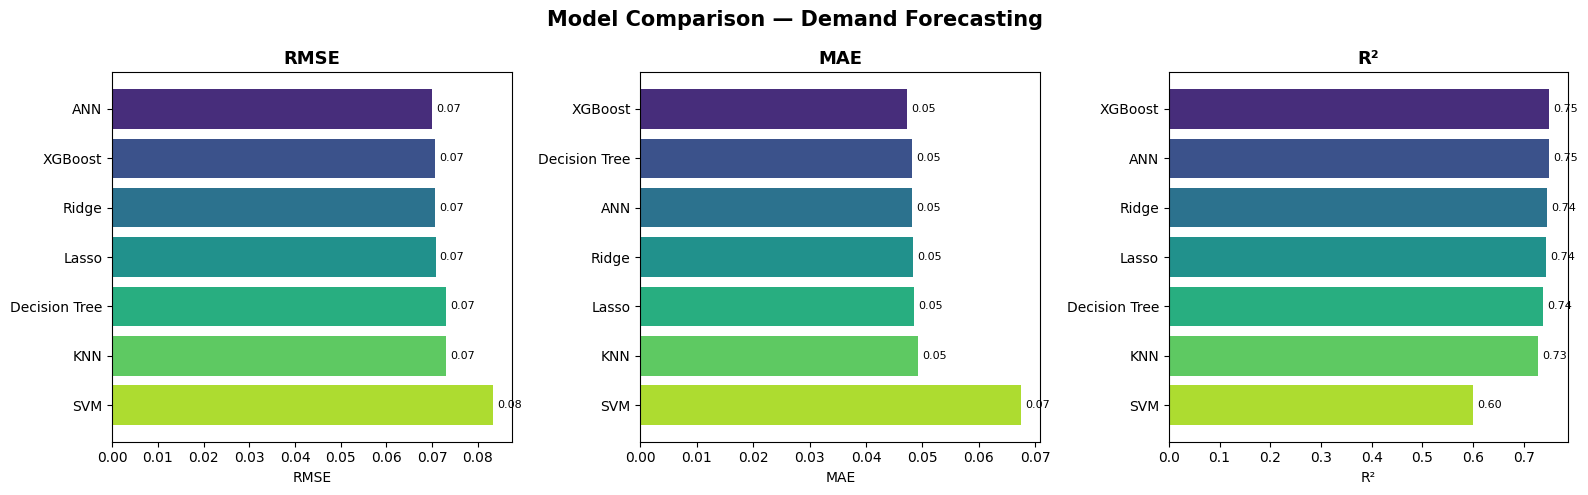

In [41]:
"""
Paste these cells into your Colab notebook after the encoded_df is clean.
"""

# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# ── Cell 2: Prepare features ─────────────────────────────────────────────────
# Drop non-feature columns
drop_cols = ['geohash', 'timestamp', 'demand']
feature_cols = [c for c in encoded_df.columns if c not in drop_cols]

X = encoded_df[feature_cols]
y = np.log1p(encoded_df['demand'])          # log-transform (right-skewed)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Cell 3: Define models ─────────────────────────────────────────────────────
models = {
    "Ridge":         Ridge(alpha=1.0),
    "Lasso":         Lasso(alpha=0.001, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "KNN":           KNeighborsRegressor(n_neighbors=10),
    "SVM":           SVR(kernel='rbf', C=10, epsilon=0.1),
    "ANN":           MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=300,
                                  random_state=42, early_stopping=True),
    "XGBoost":       XGBRegressor(n_estimators=500, learning_rate=0.05,
                                  max_depth=6, subsample=0.8,
                                  colsample_bytree=0.8, random_state=42,
                                  tree_method='hist'),
}

# ── Cell 4: Train & evaluate ──────────────────────────────────────────────────
results = []

for name, model in models.items():
    # Tree-based & XGBoost use unscaled; linear/distance-based use scaled
    if name in ("Ridge", "Lasso", "KNN", "SVM", "ANN"):
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # Back-transform predictions for interpretable MAE/RMSE
    preds_orig = np.expm1(preds)
    y_test_orig = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_orig, preds_orig))
    mae  = mean_absolute_error(y_test_orig, preds_orig)
    r2   = r2_score(y_test, preds)           # R² on log scale

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    print(f"{name:<15}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
print("\n", results_df.to_string(index=False))

# ── Cell 5: Comparison plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["RMSE", "MAE", "R²"]
colors  = sns.color_palette("viridis", len(results_df))

for ax, metric in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=(metric != "R²"))
    bars = ax.barh(sorted_df["Model"], sorted_df[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.invert_yaxis()

plt.suptitle("Model Comparison — Demand Forecasting", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [42]:
encoded_df.to_csv("encoded_df.csv", index=False)

In [43]:
!pip install -r requirements.txt

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

import pygeohash as pgh

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

In [45]:
# ── Load ──────────────────────────────────────────────────────────────────────
encoded_df = pd.read_csv('encoded_df.csv')

# ── Feature Engineering ───────────────────────────────────────────────────────
fe_df = encoded_df.copy()

# Fix: Create a full datetime by combining 'day' and 'timestamp'
# Assuming 'day' represents days from a conceptual start point, e.g., 2023-01-01
base_date = pd.to_datetime('2023-01-01')

# Create a temporary 'date' part from 'base_date' and 'day'
fe_df['date_part'] = base_date + pd.to_timedelta(fe_df['day'], unit='D')

# Combine the 'date_part' (formatted as YYYY-MM-DD) with the 'timestamp' (HH:MM)
fe_df['full_datetime_str'] = fe_df['date_part'].dt.strftime('%Y-%m-%d') + ' ' + fe_df['timestamp']

# Convert the combined string to datetime
fe_df['timestamp'] = pd.to_datetime(fe_df['full_datetime_str'])

# Drop the temporary columns
fe_df.drop(columns=['date_part', 'full_datetime_str'], inplace=True)


fe_df['hour']        = fe_df['timestamp'].dt.hour
fe_df['day_of_week'] = fe_df['timestamp'].dt.dayofweek
fe_df['month']       = fe_df['timestamp'].dt.month
fe_df['is_weekend']  = (fe_df['day_of_week'] >= 5).astype(int)
fe_df['is_peak']     = fe_df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

fe_df['hour_sin']  = np.sin(2 * np.pi * fe_df['hour'] / 24)
fe_df['hour_cos']  = np.cos(2 * np.pi * fe_df['hour'] / 24)
fe_df['dow_sin']   = np.sin(2 * np.pi * fe_df['day_of_week'] / 7)
fe_df['dow_cos']   = np.cos(2 * np.pi * fe_df['day_of_week'] / 7)
fe_df['month_sin'] = np.sin(2 * np.pi * fe_df['month'] / 12)
fe_df['month_cos'] = np.cos(2 * np.pi * fe_df['month'] / 12)

def safe_decode(gh):
    try:
        lat, lon = pgh.decode(gh)
        return pd.Series([lat, lon])
    except Exception:
        return pd.Series([np.nan, np.nan])

fe_df[['lat', 'lon']] = fe_df['geohash'].apply(safe_decode)
fe_df['lat'].fillna(fe_df['lat'].mean(), inplace=True)
fe_df['lon'].fillna(fe_df['lon'].mean(), inplace=True)

fe_df['temp_x_peak']          = fe_df['Temperature'] * fe_df['is_peak']
fe_df['lanes_x_highway']      = fe_df['NumberofLanes'] * fe_df['RoadType_Highway']
fe_df['temp_x_weather_rainy'] = fe_df['Temperature'] * fe_df['Weather_Rainy']
fe_df['temp_x_weather_snowy'] = fe_df['Temperature'] * fe_df['Weather_Snowy']
fe_df['temp_x_weather_foggy'] = fe_df['Temperature'] * fe_df['Weather_Foggy']

fe_df['geohash_mean_demand'] = np.nan  # filled post-split

print("Feature engineering done. Shape:", fe_df.shape)

Feature engineering done. Shape: (77299, 36)


In [46]:
# ── Train/Test Split + Target Encoding ───────────────────────────────────────
drop_cols    = ['geohash', 'timestamp', 'demand']
feature_cols = [c for c in fe_df.columns if c not in drop_cols]

X = fe_df[feature_cols]
y = np.log1p(fe_df['demand'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_idx = X_train.index
test_idx  = X_test.index

# Build geohash map from train only — save for test.py
gh_map = fe_df.loc[train_idx].groupby('geohash')['demand'].mean()
gh_fallback = fe_df.loc[train_idx, 'demand'].mean()

X_train = X_train.copy()
X_test  = X_test.copy()
X_train['geohash_mean_demand'] = fe_df.loc[train_idx, 'geohash'].map(gh_map).values
X_test['geohash_mean_demand']  = fe_df.loc[test_idx, 'geohash'].map(gh_map).fillna(gh_fallback).values

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── Models ────────────────────────────────────────────────────────────────────
models = {
    "Ridge":         Ridge(alpha=1.0),
    "Lasso":         Lasso(alpha=0.001, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42),
    "KNN":           KNeighborsRegressor(n_neighbors=10, weights='distance'),
    "SVM":           SVR(kernel='rbf', C=10, epsilon=0.05),
    "ANN":           MLPRegressor(
                         hidden_layer_sizes=(256, 128, 64),
                         activation='relu', max_iter=500,
                         learning_rate_init=0.001,
                         early_stopping=True, random_state=42
                     ),
    "XGBoost":       XGBRegressor(
                         n_estimators=800, learning_rate=0.05,
                         max_depth=6, subsample=0.8,
                         colsample_bytree=0.8, min_child_weight=5,
                         reg_alpha=0.1, reg_lambda=1.0,
                         random_state=42, tree_method='hist'
                     ),
}


Train: (61839, 33), Test: (15460, 33)


In [47]:
# ── Train & Evaluate ──────────────────────────────────────────────────────────
SCALED  = {"Ridge", "Lasso", "KNN", "SVM", "ANN"}
results = []

for name, model in models.items():
    Xtr, Xte = (X_train_sc, X_test_sc) if name in SCALED else (X_train, X_test)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    preds_orig  = np.expm1(preds)
    y_test_orig = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_orig, preds_orig))
    mae  = mean_absolute_error(y_test_orig, preds_orig)
    r2   = r2_score(y_test, preds)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    print(f"{name:<15}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
print("\n", results_df.to_string(index=False))

Ridge            RMSE=0.0529  MAE=0.0347  R²=0.8560
Lasso            RMSE=0.0531  MAE=0.0349  R²=0.8550
Decision Tree    RMSE=0.0385  MAE=0.0241  R²=0.9219
KNN              RMSE=0.0456  MAE=0.0299  R²=0.8904
SVM              RMSE=0.0425  MAE=0.0284  R²=0.9051
ANN              RMSE=0.0379  MAE=0.0240  R²=0.9255
XGBoost          RMSE=0.0312  MAE=0.0209  R²=0.9451

         Model     RMSE      MAE       R²
      XGBoost 0.031215 0.020891 0.945056
          ANN 0.037876 0.024008 0.925526
Decision Tree 0.038501 0.024087 0.921950
          SVM 0.042540 0.028369 0.905113
          KNN 0.045580 0.029940 0.890429
        Ridge 0.052884 0.034674 0.856028
        Lasso 0.053145 0.034865 0.855010


Ridge            RMSE=0.0529  MAE=0.0347  R²=0.8560
Lasso            RMSE=0.0531  MAE=0.0349  R²=0.8550
Decision Tree    RMSE=0.0385  MAE=0.0241  R²=0.9219
KNN              RMSE=0.0456  MAE=0.0299  R²=0.8904
SVM              RMSE=0.0425  MAE=0.0284  R²=0.9051
ANN              RMSE=0.0379  MAE=0.0240  R²=0.9255
XGBoost          RMSE=0.0312  MAE=0.0209  R²=0.9451

         Model     RMSE      MAE       R²
      XGBoost 0.031215 0.020891 0.945056
          ANN 0.037876 0.024008 0.925526
Decision Tree 0.038501 0.024087 0.921950
          SVM 0.042540 0.028369 0.905113
          KNN 0.045580 0.029940 0.890429
        Ridge 0.052884 0.034674 0.856028
        Lasso 0.053145 0.034865 0.855010


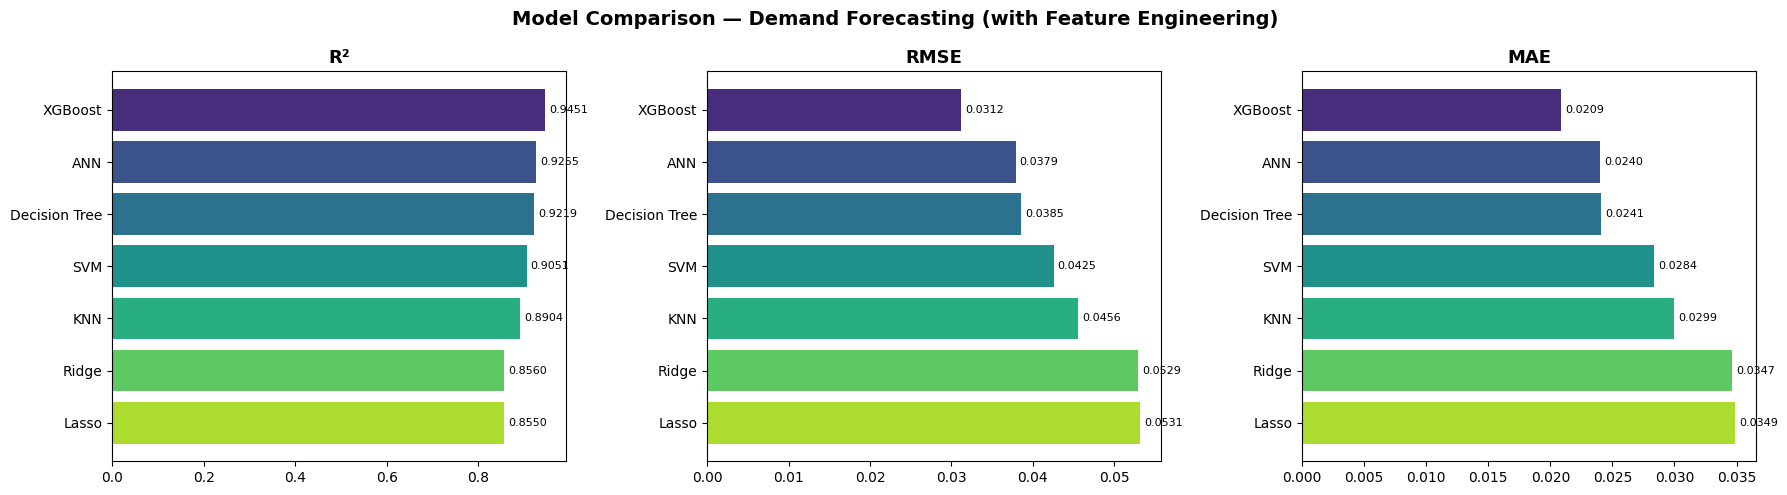

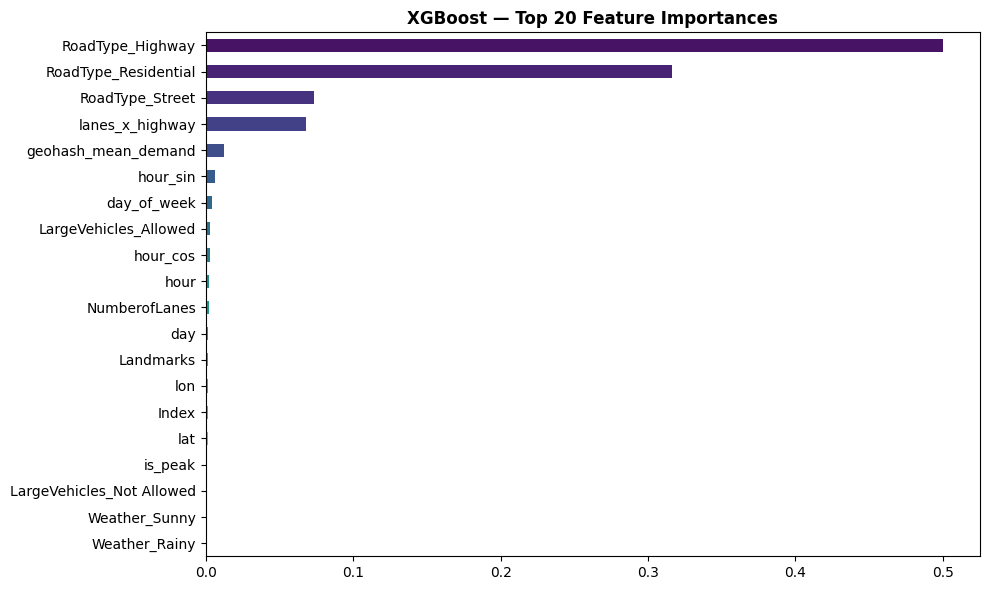

In [48]:
SCALED  = {"Ridge", "Lasso", "KNN", "SVM", "ANN" }
results = []

for name, model in models.items():
    Xtr, Xte = (X_train_sc, X_test_sc) if name in SCALED else (X_train, X_test)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    preds_orig  = np.expm1(preds)
    y_test_orig = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_orig, preds_orig))
    mae  = mean_absolute_error(y_test_orig, preds_orig)
    r2   = r2_score(y_test, preds)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    print(f"{name:<15}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
print("\n", results_df.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette   = sns.color_palette("viridis", len(results_df))
metrics   = ["R²", "RMSE", "MAE"]
ascending = [False, True, True]

for ax, metric, asc in zip(axes, metrics, ascending):
    sdf  = results_df.sort_values(metric, ascending=asc)
    bars = ax.barh(sdf["Model"], sdf[metric], color=palette)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.invert_yaxis()

plt.suptitle("Model Comparison — Demand Forecasting (with Feature Engineering)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison_fe.png", dpi=150, bbox_inches='tight')
plt.show()

# XGBoost feature importance
xgb_model   = models["XGBoost"]
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color=sns.color_palette("viridis", 20))
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 20 Feature Importances", fontweight='bold')
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

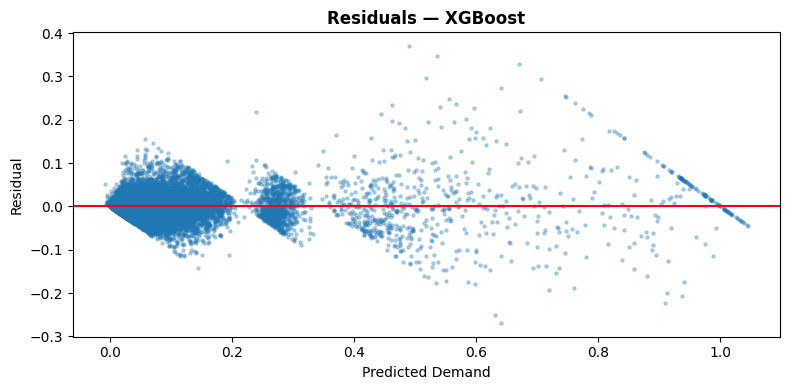

In [49]:
# Residuals
Xte_use    = X_test
best_preds = np.expm1(xgb_model.predict(Xte_use))
residuals  = np.expm1(y_test.values) - best_preds

plt.figure(figsize=(8, 4))
plt.scatter(best_preds, residuals, alpha=0.3, s=5)
plt.axhline(0, color='red', lw=1.5)
plt.xlabel("Predicted Demand")
plt.ylabel("Residual")
plt.title("Residuals — XGBoost", fontweight='bold')
plt.tight_layout()
plt.savefig("residuals.png", dpi=150, bbox_inches='tight')
plt.show()


In [50]:
# ── Retrain XGBoost on FULL data + save artifacts ────────────────────────────
print("\nRetraining XGBoost on full dataset...")

X_full = fe_df[feature_cols].copy()
y_full = np.log1p(fe_df['demand'])

gh_map_full     = fe_df.groupby('geohash')['demand'].mean()
gh_fallback_full = fe_df['demand'].mean()
X_full['geohash_mean_demand'] = fe_df['geohash'].map(gh_map_full).values

final_model = XGBRegressor(
    n_estimators=800, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, tree_method='hist'
)
final_model.fit(X_full, y_full)

# Save artifacts
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('gh_map.pkl', 'wb') as f:
    pickle.dump({'gh_map': gh_map_full, 'fallback': gh_fallback_full}, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(X_full.columns.tolist(), f)

print("Saved: xgb_model.pkl, gh_map.pkl, feature_cols.pkl")


Retraining XGBoost on full dataset...
Saved: xgb_model.pkl, gh_map.pkl, feature_cols.pkl


In [52]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import pygeohash as pgh
from sklearn.impute import SimpleImputer

# ── Load artifacts ────────────────────────────────────────────────────────────
with open('xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('gh_map.pkl', 'rb') as f:
    gh_artifacts = pickle.load(f)
    gh_map       = gh_artifacts['gh_map']
    gh_fallback  = gh_artifacts['fallback']

with open('feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("Artifacts loaded.")

# ── Load & preprocess test.csv ────────────────────────────────────────────────
df_test = pd.read_csv('test.csv')

Artifacts loaded.


In [53]:
# Impute
road_imputer    = SimpleImputer(strategy='most_frequent')
weather_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

df_test['RoadType']    = road_imputer.fit_transform(df_test[['RoadType']]).ravel()
df_test['Weather']     = weather_imputer.fit_transform(df_test[['Weather']]).ravel()
df_test['Temperature'] = df_test['Temperature'].fillna(df_test['Temperature'].mean())
df_test['Landmarks']   = (df_test['Landmarks'] == "Yes").astype(int)

# One-hot encode
df_test = pd.get_dummies(df_test, columns=['RoadType', 'LargeVehicles', 'Weather'], dtype=int)

# ── Feature Engineering (same as train.py) ────────────────────────────────────
def safe_decode(gh):
    try:
        lat, lon = pgh.decode(gh)
        return pd.Series([lat, lon])
    except Exception:
        return pd.Series([np.nan, np.nan])

df_test['timestamp']   = pd.to_datetime(df_test['timestamp'])
df_test['hour']        = df_test['timestamp'].dt.hour
df_test['day_of_week'] = df_test['timestamp'].dt.dayofweek
df_test['month']       = df_test['timestamp'].dt.month
df_test['is_weekend']  = (df_test['day_of_week'] >= 5).astype(int)
df_test['is_peak']     = df_test['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

df_test['hour_sin']  = np.sin(2 * np.pi * df_test['hour'] / 24)
df_test['hour_cos']  = np.cos(2 * np.pi * df_test['hour'] / 24)
df_test['dow_sin']   = np.sin(2 * np.pi * df_test['day_of_week'] / 7)
df_test['dow_cos']   = np.cos(2 * np.pi * df_test['day_of_week'] / 7)
df_test['month_sin'] = np.sin(2 * np.pi * df_test['month'] / 12)
df_test['month_cos'] = np.cos(2 * np.pi * df_test['month'] / 12)

df_test[['lat', 'lon']] = df_test['geohash'].apply(safe_decode)
df_test['lat'].fillna(df_test['lat'].mean(), inplace=True)
df_test['lon'].fillna(df_test['lon'].mean(), inplace=True)


0        90.664673
1        90.686646
2        90.653687
3        90.675659
4        90.686646
           ...    
41773    90.807495
41774    90.818481
41775    90.895386
41776    90.906372
41777    90.939331
Name: lon, Length: 41778, dtype: float64

In [54]:
df_test['temp_x_peak']          = df_test['Temperature'] * df_test['is_peak']
df_test['lanes_x_highway']      = df_test['NumberofLanes'] * df_test.get('RoadType_Highway', 0)
df_test['temp_x_weather_rainy'] = df_test['Temperature'] * df_test.get('Weather_Rainy', 0)
df_test['temp_x_weather_snowy'] = df_test['Temperature'] * df_test.get('Weather_Snowy', 0)
df_test['temp_x_weather_foggy'] = df_test['Temperature'] * df_test.get('Weather_Foggy', 0)

# Geohash target encoding using train map
df_test['geohash_mean_demand'] = df_test['geohash'].map(gh_map).fillna(gh_fallback)

# ── Align columns with training ───────────────────────────────────────────────
for col in feature_cols:
    if col not in df_test.columns:
        df_test[col] = 0

X_test_final = df_test[feature_cols]

print("Test shape:", X_test_final.shape)
print("Nulls:", X_test_final.isnull().sum().sum())

# ── Predict ───────────────────────────────────────────────────────────────────
preds_log  = model.predict(X_test_final)
preds_orig = np.expm1(preds_log)

print(f"Pred range: {preds_orig.min():.4f} – {preds_orig.max():.4f}")


Test shape: (41778, 33)
Nulls: 0
Pred range: -0.0073 – 1.0720


In [55]:
# ── Submission ────────────────────────────────────────────────────────────────
# Create submission with test Index and predictions
submission = pd.DataFrame({
    'Index': df_test['Index'].values,
    'demand': preds_orig
})

submission.to_csv('submission.csv', index=False)
print("submission.csv saved. Shape:", submission.shape)
print(submission.head())

submission.csv saved. Shape: (41778, 2)
   Index    demand
0      0  0.029342
1      1  0.024436
2      2  0.019369
3      3  0.025915
4      4  0.028516
